# 任务一：Iris 数据集分类任务实践

这个 notebook 按照实验题目的顺序来完成 Iris 分类任务。

你可以把它理解成下面 7 个步骤：

1. 导入实验所需的库，并设置绘图风格。
2. 加载 Iris 数据集，查看数据规模、特征名、类别分布和统计信息。
3. 绘制散点矩阵图，观察不同类别在特征空间中的分布情况。
4. 按 7:3 划分训练集和测试集，并按题目要求完成标准化。
5. 训练 4 个分类模型，并计算准确率、精确率、召回率和 F1 分数。
6. 把评估结果画成图，便于横向比较。
7. 画出一棵深度为 3 的决策树，帮助理解分类规则。

建议运行方式：从上到下依次执行，不要跳步。

## 第 1 步：导入库并设置实验环境

这一格主要做三件事：

- 导入数据处理、画图和机器学习所需的库。
- 设置随机种子，保证你多次运行时结果一致。
- 定义“手动标准化”函数，和题目中的标准化公式保持一致。

In [1]:
# 忽略一些不影响实验结论的警告，让输出更干净
import warnings
warnings.filterwarnings("ignore")

# 导入常用的数据处理与可视化库
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# display 可以让 DataFrame 在 notebook 中显示得更整齐
from IPython.display import display

# 导入 Iris 数据集和后续会用到的机器学习工具
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 设置 seaborn 的默认风格，让图更清晰
sns.set_theme(style="whitegrid")

# 设置中文字体，避免图中的中文标题出现乱码
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 固定随机种子，保证训练集划分和模型结果可复现
RANDOM_STATE = 42


def manual_standardize(train_df, test_df):
    """
    按实验题要求手动完成标准化：
    X_scaled = (X - mean) / std

    注意：
    1. 均值和标准差只能用训练集计算；
    2. 测试集必须使用训练集的均值和标准差来变换，
       这样才符合机器学习的规范流程。
    """
    mean = train_df.mean()
    std = train_df.std(ddof=0).replace(0, 1)
    train_scaled = (train_df - mean) / std
    test_scaled = (test_df - mean) / std
    return train_scaled, test_scaled, mean, std


    

## 第 2 步：加载数据并做基础探索

这一格的目标是先“认识数据”。

我们会查看：

- 数据一共有多少行、多少列；
- 每个特征叫什么名字；
- 三个类别分别有多少条样本；
- 每个特征的大致取值范围、均值、标准差等统计量。

In [6]:
# 以 DataFrame 的形式加载 Iris 数据集，方便后续分析
iris = load_iris(as_frame=True)

# X 表示输入特征，y 表示分类标签
X = iris.data.copy()
y = iris.target.copy()

# 保存特征名称和类别名称，后面画图时会用到
feature_names = iris.feature_names
class_names = iris.target_names

# 构造一个带文字类别名的数据表，便于可视化
df = X.copy()
df["species"] = y.map(dict(enumerate(class_names)))

# 查看数据规模
print("数据规模：", X.shape)

# 查看特征名称
print("特征名称：", feature_names)

# 查看三类花的样本数量是否平衡
print("\n类别分布：")
display(df["species"].value_counts().rename("count").to_frame())

# 看前几行，帮助理解每一列长什么样
print("\n前 5 行数据：")
display(df.head())

# describe() 可以快速查看均值、标准差、最大值、最小值等统计量
print("\n描述性统计：")
display(X.describe())

数据规模： (150, 4)
特征名称： ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

类别分布：


,count
species,
setosa,50
versicolor,50
virginica,50



前 5 行数据：


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



描述性统计：


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 第 3 步：绘制特征散点矩阵

散点矩阵图的作用是：

- 观察单个特征的分布；
- 观察不同特征两两组合时，不同类别是否容易分开；
- 帮助我们直观判断这个分类问题是容易还是困难。

如果某些类别在图里分得很开，通常意味着模型更容易学到规律。

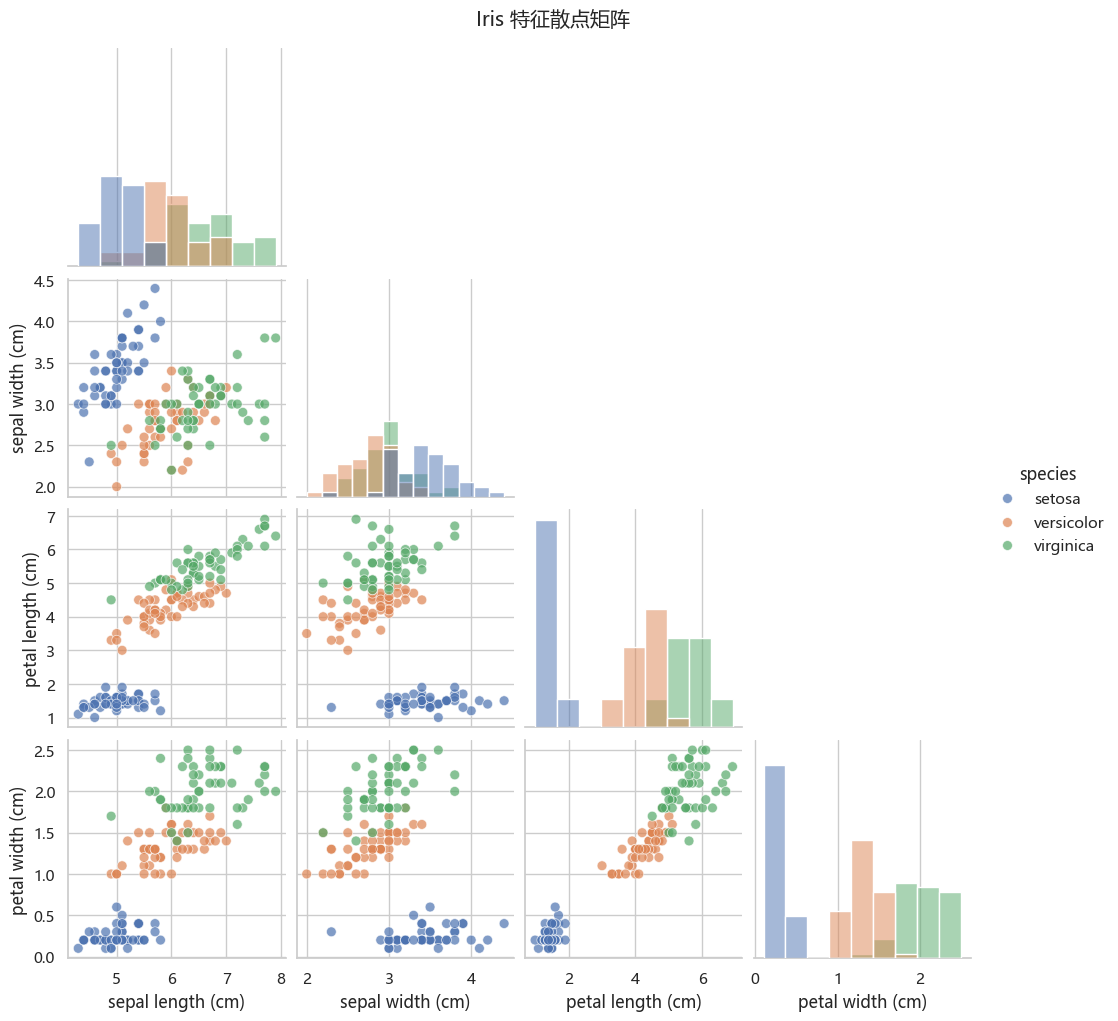

In [7]:
# pairplot 会把多个特征两两组合成散点图，同时在对角线上显示单变量分布
sns.pairplot(
    df,
    hue="species",         # 按类别上色
    corner=True,           # 只显示下三角，避免重复
    diag_kind="hist",      # 对角线上画直方图
    plot_kws={"alpha": 0.7, "s": 50},
)

plt.suptitle("Iris 特征散点矩阵", y=1.02)
plt.show()

## 第 4 步：划分训练集和测试集，并进行标准化

这一步是标准机器学习流程中的关键部分。

- 训练集：用来训练模型。
- 测试集：用来评估模型是否真的学会了规律。

这里按题目要求使用 7:3 划分。

另外，因为题目明确要求标准化，所以我们按照训练集的均值和标准差对数据进行变换。

In [8]:
# 按 7:3 划分训练集和测试集
# stratify=y 表示按类别分层抽样，保证训练集和测试集中的类别比例接近原始数据
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 按题目要求手动标准化
X_train_scaled, X_test_scaled, train_mean, train_std = manual_standardize(X_train, X_test)

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

# 输出训练集的均值和标准差，帮助理解标准化是基于哪些统计量完成的
print("\n训练集均值：")
display(train_mean.to_frame(name="mean").T)

print("\n训练集标准差：")
display(train_std.to_frame(name="std").T)

训练集大小： (105, 4)
测试集大小： (45, 4)

训练集均值：


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,5.873333,3.055238,3.784762,1.205714



训练集标准差：


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
std,0.858822,0.455021,1.775536,0.773838


## 第 5 步：训练 4 个分类模型并计算指标

题目要求使用以下 4 个模型：

- LogisticRegression
- DecisionTreeClassifier
- RandomForestClassifier
- SVC（RBF 核）

对每个模型，我们都在测试集上计算：

- Accuracy
- Precision（macro）
- Recall（macro）
- F1（macro）

这里使用 `macro` 的原因是：它会对每个类别分别计算指标，再取平均，更适合多分类任务的整体比较。

In [9]:
# 按题目要求实例化 4 个分类模型，保持默认参数
models = {
    "LogisticRegression": LogisticRegression(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(),
    "SVC(RBF)": SVC(),
}

# 用来保存每个模型的评估结果
results = []

# 用来保存训练好的模型，后面如果想继续分析可以直接使用
fitted_models = {}

# 依次训练每一个模型，并在测试集上进行评估
for name, model in models.items():
    # 模型在标准化后的训练集上学习
    model.fit(X_train_scaled, y_train)

    # 使用测试集做预测
    y_pred = model.predict(X_test_scaled)

    # 保存训练完成的模型
    fitted_models[name] = model

    # 计算题目要求的 4 个分类指标
    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        }
    )

# 整理成 DataFrame，便于查看和后续画图
results_df = pd.DataFrame(results).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,SVC(RBF),0.933333,0.934524,0.933333,0.933259
1,DecisionTreeClassifier,0.911111,0.911111,0.911111,0.911111
2,LogisticRegression,0.911111,0.915535,0.911111,0.910714
3,RandomForestClassifier,0.911111,0.915535,0.911111,0.910714


## 第 6 步：把模型指标画成柱状图

单看表格有时候不够直观，所以我们进一步把指标画成柱状图。

这样可以更快看出：

- 哪个模型整体表现最好；
- 哪些模型在不同指标上的表现更均衡；
- 是否存在某个模型准确率很高，但其他指标一般的情况。

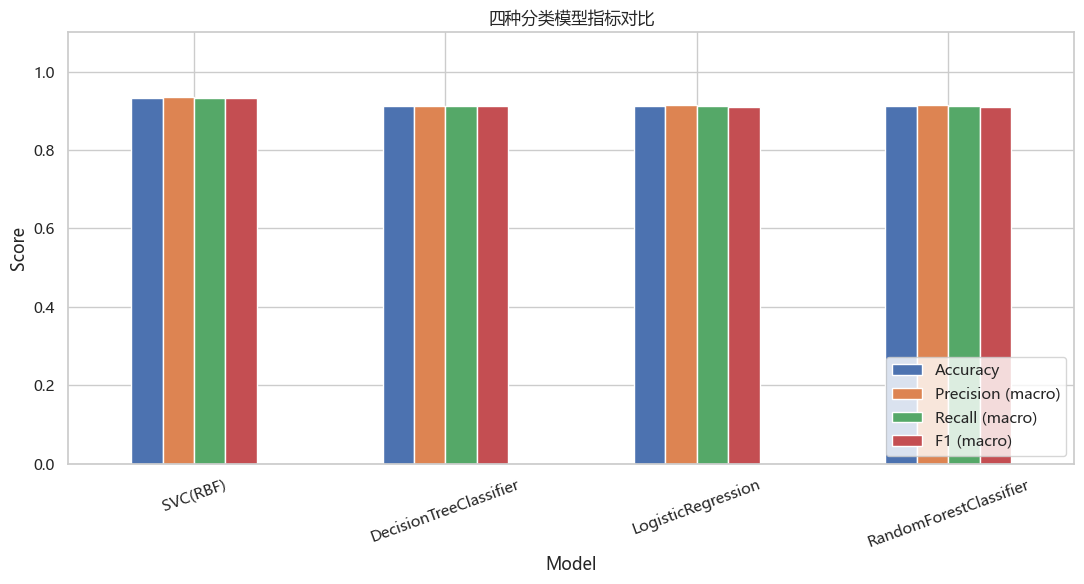

In [10]:
# 选择要比较的指标列
metric_columns = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]

# 把模型名称设为索引，方便直接画分组柱状图
plot_df = results_df.set_index("Model")[metric_columns]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("四种分类模型指标对比")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)

plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 第 7 步：可视化深度为 3 的决策树

决策树的一个优势就是“可解释性强”。

我们这里专门训练一棵深度为 3 的树，并把它画出来，目的是：

- 观察每次分裂用了哪个特征；
- 看每个节点是如何一步步把样本分类开的；
- 理解决策树“按条件逐层判断”的工作方式。

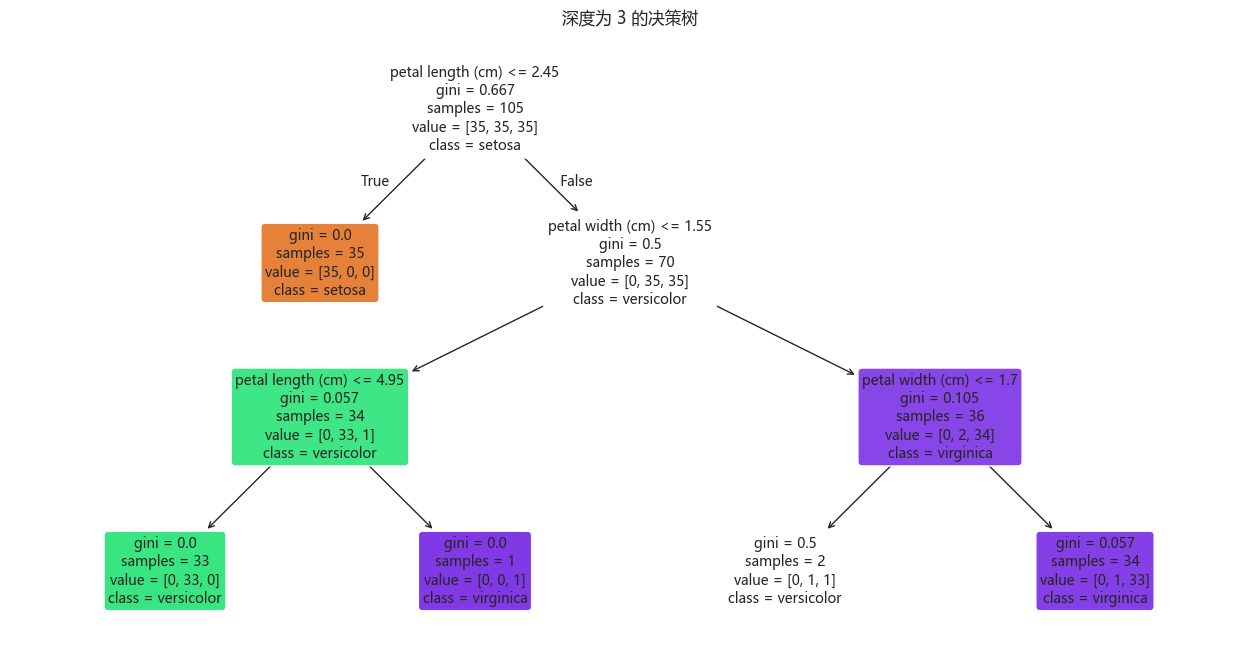

In [11]:
# 单独训练一棵浅层树，深度限制为 3，便于可视化和解释
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
shallow_tree.fit(X_train, y_train)

# 画出决策树结构
plt.figure(figsize=(16, 8))
plot_tree(
    shallow_tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
)

plt.title("深度为 3 的决策树")
plt.show()

## 实验结论参考写法

你在写报告时可以从下面几个角度展开：

- Iris 数据集的类别区分度较高，所以多个分类模型通常都能取得不错结果。
- 逻辑回归和 SVM 往往表现较稳，因为 Iris 的类别边界相对清晰。
- 单棵决策树可解释性很强，但更容易因为树太深而过拟合。
- 随机森林通过集成多棵树，通常会比单棵树更稳定。
- 从散点矩阵和指标对比图可以看出，花瓣长度、花瓣宽度这类特征通常对分类更有帮助。